# Step 7 — Asset Vulnerability Mapping

**Objective:** Overlay HIFLD grid infrastructure (substations, transmission lines) with LOCA2 projected heat hazard and CAISO wildfire zones to produce a county-level asset risk score.

**Output:** `data/processed/asset_risk_scores.csv` and choropleth maps.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

from config.settings import RAW, PROCESSED, ERCOT_FIPS, CAISO_FIPS, ASSET_RISK_WEIGHTS
from src.viz.maps import choropleth_county


## 7.1 Load HIFLD substations

Download from: https://catalog.data.gov/dataset/electric-substations  
Save shapefile to `data/raw/hifld/Electric_Substations.shp`.

In [2]:
substation_path = RAW['hifld'] / 'Electric_Substations.shp'
if substation_path.exists():
    substations = gpd.read_file(substation_path)
    print(f'Substations loaded: {len(substations):,}')
    print(substations.head())
else:
    print('Substation file not found.')
    substations = None


Substations loaded: 9,461
       ID           NAME        CITY STATE         COUNTY COUNTYFIPS  \
0  156744  UNKNOWN156744   TEXARKANA    TX          BOWIE      48037   
1  161924      TAP161924     JOAQUIN    TX         SHELBY      48419   
2  161925  UNKNOWN161925     JOAQUIN    TX         SHELBY      48419   
3  166905  UNKNOWN166905  WELLINGTON    TX  COLLINGSWORTH      48087   
4  172446      TAP172446    CARTHAGE    TX         PANOLA      48365   

         TYPE         STATUS   LATITUDE   LONGITUDE  MAX_VOLT  MIN_VOLT  \
0  SUBSTATION     IN SERVICE  33.518004  -94.084688      69.0      69.0   
1         TAP     IN SERVICE  31.959767  -94.038401 -999999.0 -999999.0   
2  SUBSTATION     IN SERVICE  31.959443  -94.038137 -999999.0 -999999.0   
3  SUBSTATION  NOT AVAILABLE  34.853890 -100.209633 -999999.0 -999999.0   
4         TAP  NOT AVAILABLE  32.159666  -94.286317 -999999.0 -999999.0   

    LINES                     geometry  
0       1     POINT (-94.08469 33.518)  
1       

## 7.2 Load HIFLD transmission lines

Download from: https://gis-fws.opendata.arcgis.com/datasets/fws::us-electric-power-transmission-lines

In [3]:
txline_path = RAW['hifld'] / 'Electric_Power_Transmission_Lines.shp'
if txline_path.exists():
    txlines = gpd.read_file(txline_path)
    print(f'Transmission line segments: {len(txlines):,}')
else:
    print('Transmission line file not found.')
    txlines = None


Transmission line segments: 94,619


## 7.3 Load county geometries and spatial join

In [4]:
tiger_path = RAW['hifld'] / 'tl_2023_us_county' / 'tl_2023_us_county.shp'
study_counties = None
if tiger_path.exists():
    counties = gpd.read_file(tiger_path)
    counties['fips'] = counties['GEOID'].astype(str).str.zfill(5)
    study_counties = counties[counties['fips'].isin(set(ERCOT_FIPS + CAISO_FIPS))].to_crs('EPSG:4326')
    print(f'Study counties: {len(study_counties)}')

if substations is not None and study_counties is not None:
    subs_proj = substations.to_crs('EPSG:4326')
    subs_county = gpd.sjoin(subs_proj, study_counties[['fips', 'geometry']], how='left', predicate='within')
    substation_counts = subs_county.groupby('fips').size().rename('n_substations')
    print('Top 10 counties by substation count:')
    print(substation_counts.nlargest(10))


Study counties: 312
Top 10 counties by substation count:
fips
06037    559
48201    386
06067    371
06029    330
06071    274
48113    267
06065    210
06059    190
06073    163
48439    156
Name: n_substations, dtype: int64


## 7.4 Compute composite asset risk score

Score = 0.40 * heat_exposure_rank + 0.30 * wildfire_exposure_rank + 0.30 * asset_density_rank
(wildfire_exposure_rank = 0 for ERCOT counties)

In [5]:
risk_frames = []
for fips_list, path, region in [
    (ERCOT_FIPS, PROCESSED['loca2_ercot'], 'ERCOT'),
    (CAISO_FIPS, PROCESSED['loca2_caiso'], 'CAISO')
]:
    if not path.exists():
        print(f'LOCA2 not found for {region}')
        continue
    proj = pd.read_csv(path, dtype={'fips': str})
    mid = proj[(proj['scenario'] == 'ssp585') & (proj['period_label'] == 'mid')].copy()
    # Prefer per-county NEX-GDDP TXx delta (NB05 injects this column when NEX-GDDP run available);
    # fall back to WSDI_delta (uniform per region under AR6 synthesis).
    if 'TXx_nex_delta' in mid.columns and mid['TXx_nex_delta'].notna().any():
        mid['heat_exposure_rank'] = rankdata(mid['TXx_nex_delta'].fillna(mid['TXx_nex_delta'].median())) / len(mid)
    elif 'WSDI_delta' in mid.columns:
        mid['heat_exposure_rank'] = rankdata(mid['WSDI_delta'].fillna(0)) / len(mid)
    else:
        mid['heat_exposure_rank'] = 0.0
    mid['region'] = region

    # Asset density rank: substations per county area
    if 'substation_counts' in dir() and study_counties is not None:
        county_area = study_counties.set_index('fips')['geometry'].to_crs('EPSG:5070').area / 1e6  # km2
        sub_density = substation_counts.reindex(mid['fips'].values).fillna(0)
        area_km2 = county_area.reindex(mid['fips'].values).fillna(1)
        density_vals = (sub_density.values / area_km2.values)
        mid['asset_density_rank'] = rankdata(density_vals) / len(mid)
    else:
        mid['asset_density_rank'] = 0.5  # neutral placeholder if substations unavailable

    # Wildfire exposure rank: CAISO only (CAL FIRE FHSZ)
    fhsz_path = RAW['hifld'] / 'cal_fire_fhsz'
    if region == 'CAISO' and fhsz_path.exists() and txlines is not None and study_counties is not None:
        fhsz = gpd.read_file(fhsz_path).to_crs('EPSG:4326')
        high_fhsz = fhsz[fhsz.get('HAZ_CLASS', fhsz.columns[0]).isin(['Very High', 'VH'])]
        caiso_counties = study_counties[study_counties['fips'].isin(fips_list)].to_crs('EPSG:4326')
        caiso_lines = txlines.to_crs('EPSG:4326').clip(caiso_counties.union_all())
        lines_fhsz = gpd.overlay(caiso_lines, high_fhsz[['geometry']], how='intersection')
        # Use representative_point + sjoin to ensure 1-to-1 mapping
        lf_pts = lines_fhsz.copy()
        lf_pts['geometry'] = lf_pts.geometry.representative_point()
        joined = gpd.sjoin(
            lf_pts[['geometry']], caiso_counties[['fips', 'geometry']],
            how='left', predicate='within'
        )
        # Keep first match only (some points may sit on borders)
        joined = joined[~joined.index.duplicated(keep='first')]
        lines_fhsz['county_fips'] = joined['fips'].reindex(lines_fhsz.index).values
        wf_km = lines_fhsz.to_crs('EPSG:5070').geometry.length.groupby(
            lines_fhsz['county_fips']
        ).sum() / 1000
        mid['wildfire_exposure_rank'] = rankdata(
            mid['fips'].map(wf_km).fillna(0)
        ) / len(mid)
    else:
        mid['wildfire_exposure_rank'] = 0.0  # zero for ERCOT or if FHSZ missing

    # Composite score using ASSET_RISK_WEIGHTS
    w = ASSET_RISK_WEIGHTS
    mid['composite_risk_score'] = (
        w['heat_exposure_rank']    * mid['heat_exposure_rank'] +
        w['wildfire_exposure_rank'] * mid['wildfire_exposure_rank'] +
        w['asset_density_rank']    * mid['asset_density_rank']
    )

    risk_frames.append(
        mid[['fips', 'region', 'heat_exposure_rank',
             'wildfire_exposure_rank', 'asset_density_rank',
             'composite_risk_score']].copy()
    )

if risk_frames:
    risk_df = pd.concat(risk_frames, ignore_index=True)
    print(f'Risk scores computed for {len(risk_df)} counties')
    print(risk_df.sort_values('composite_risk_score', ascending=False).head(10))


Risk scores computed for 183 counties
      fips region  heat_exposure_rank  wildfire_exposure_rank  \
163  06073  CAISO                0.90                    0.96   
136  06013  CAISO                0.72                    0.62   
158  06061  CAISO                0.84                    0.66   
156  06057  CAISO                0.96                    0.74   
174  06097  CAISO                0.68                    0.76   
138  06017  CAISO                0.98                    0.72   
134  06007  CAISO                0.64                    0.82   
146  06037  CAISO                0.26                    1.00   
182  06115  CAISO                0.80                    0.48   
159  06065  CAISO                0.54                    0.90   

     asset_density_rank  composite_risk_score  
163                0.68                 0.852  
136                0.96                 0.762  
158                0.76                 0.762  
156                0.46                 0.744  
174   

## 7.5 Choropleth map and save

Saved: /burg-archive/home/mck2199/electric-grid-resilience/data/processed/asset_risk_scores.csv


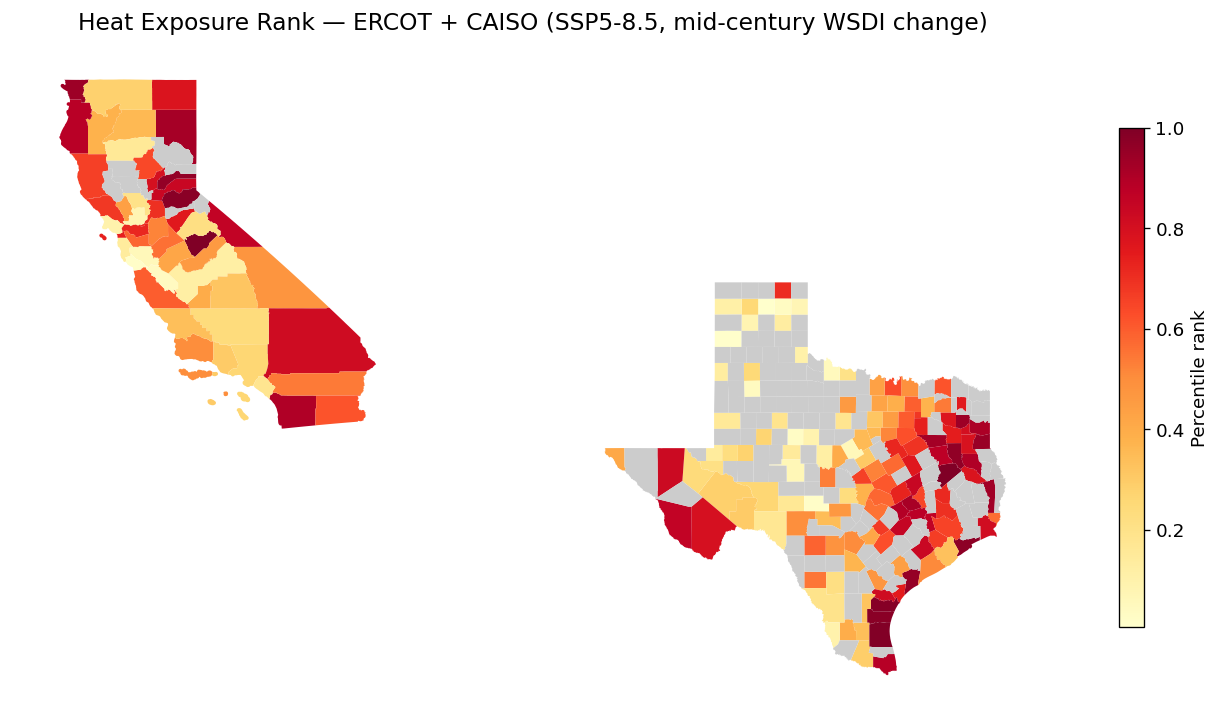

In [6]:
if 'risk_df' in dir() and study_counties is not None:
    risk_gdf = study_counties.merge(risk_df, on='fips', how='left')
    risk_df.to_csv(PROCESSED['asset_risk'], index=False)
    print('Saved:', PROCESSED['asset_risk'])

    fig, ax = plt.subplots(figsize=(14, 9))
    choropleth_county(
        risk_gdf, 'heat_exposure_rank',
        title='Heat Exposure Rank — ERCOT + CAISO (SSP5-8.5, mid-century WSDI change)',
        legend_label='Percentile rank',
        ax=ax,
    )
    plt.savefig('../data/processed/asset_heat_exposure_map.png', dpi=150, bbox_inches='tight')
    plt.show()
